# Simple Actor-Critic Implementation for the Budgeted Attack-Defense Game

In [1]:
# Importing necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Necessary imports for the attack-defense problem
from utils import prob_success, attacker_lingo_model

# Parameters
n_targets = 5 # Number of targets
alpha, beta, A = 1, 1, 0.1
attacker_budget = 5 # Attacker's investment (Million USD)
defender_budget = 30 # Defender's Investment (Million USD)

# Infrastructure valuations for n targets
B = np.array([50, 20, 35, 45, 30]) # Attacker's valuations 
D = np.array([50, 150, 100, 80, 120]) # Defender's valuations

In [3]:
# Simple 2-layer neural network for Actor
class Actor(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Actor, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, n_targets)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        x = self.fc2(x)
        # Softmax to get allocation probabilities
        return F.softmax(x, dim=-1)

# Simple 2-layer neural network for Critic
class Critic(nn.Module):
    def __init__(self, n_targets, hidden_size=64):
        super(Critic, self).__init__()
        self.fc1 = nn.Linear(n_targets, hidden_size)
        self.fc2 = nn.Linear(hidden_size, 1)
    
    def forward(self, state):
        x = F.relu(self.fc1(state))
        value = self.fc2(x)
        return value

In [4]:
# Agent class combining Actor and Critic
class Agent:
    def __init__(self, n_targets, budget, lr_actor=1e-3, lr_critic=1e-3):
        self.n_targets = n_targets
        self.budget = budget
        
        self.actor = Actor(n_targets)
        self.critic = Critic(n_targets)
        
        self.actor_optimizer = optim.Adam(self.actor.parameters(), lr=lr_actor)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr_critic)
    
    def get_allocation(self, state):
        """Get budget allocation across targets"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        probs = self.actor(state_tensor)
        
        # Sample from the distribution
        dist = torch.distributions.Categorical(probs)
        actions = dist.sample((self.budget,))
        
        # Convert to allocation vector
        allocation = torch.zeros(self.n_targets)
        for a in actions:
            allocation[a] += 1
        
        log_probs = dist.log_prob(actions).sum()
        
        return allocation, log_probs
    
    def update(self, state, log_prob, reward, next_state, gamma=0.99):
        """Update actor and critic networks"""
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        next_state_tensor = torch.FloatTensor(next_state).unsqueeze(0)
        
        # Critic update
        current_value = self.critic(state_tensor)
        next_value = self.critic(next_state_tensor)
        td_target = reward + gamma * next_value
        td_error = td_target - current_value
        
        critic_loss = td_error.pow(2).mean()
        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()
        
        # Actor update
        advantage = td_error.detach()
        actor_loss = -(log_prob * advantage)
        
        self.actor_optimizer.zero_grad()
        actor_loss.backward()
        self.actor_optimizer.step()

In [5]:
class AttackDefenseGame:
    def __init__(self, n_targets, attacker_budget, defender_budget):
        self.n_targets = n_targets
        self.attacker_budget = attacker_budget
        self.defender_budget = defender_budget
        
        # Initialize state (could be target values, vulnerabilities, etc.)
        self.state = np.ones(n_targets)
    
    def get_rewards(self, attacker_allocation, defender_allocation):
        """
        Compute rewards based on allocations using contest success function.
        Leave blank for user to implement.
        
        Args:
            attacker_allocation: torch.Tensor of shape (n_targets,)
            defender_allocation: torch.Tensor of shape (n_targets,)
        
        Returns:
            attacker_reward: float
            defender_reward: float
        """
        prob_successes = [prob_success(Ti=Ti,Gi=Gi, alpha=alpha, beta=beta, Ai=A) 
                         for Ti,Gi in zip(attacker_allocation,defender_allocation)]
        
        attacker_reward = np.dot(B, prob_successes)
        defender_reward = -1 * np.dot(D, prob_successes)
        
        return attacker_reward, defender_reward
    
    def step(self, attacker_allocation, defender_allocation):
        """Execute one step of the game"""
        attacker_reward, defender_reward = self.get_rewards(
            attacker_allocation, defender_allocation
        )
        
        # State can be updated based on game dynamics
        next_state = self.state.copy()
        
        return next_state, attacker_reward, defender_reward

## With Both Attacker and Defender As Agents

In [6]:
# Training
n_episodes=10000

game = AttackDefenseGame(n_targets, attacker_budget, defender_budget)
attacker = Agent(n_targets, attacker_budget)
defender = Agent(n_targets, defender_budget)

# To record for plots
attacker_gains = []
defender_losses = []

for episode in range(n_episodes):
    state = game.state
    
    # Get allocations from both agents
    attacker_allocation, attacker_log_prob = attacker.get_allocation(state)
    defender_allocation, defender_log_prob = defender.get_allocation(state)
    
    # Execute game step
    next_state, attacker_reward, defender_reward = game.step(
        attacker_allocation, defender_allocation
    )
    
    # Update both agents
    attacker.update(state, attacker_log_prob, attacker_reward, next_state)
    defender.update(state, defender_log_prob, defender_reward, next_state)
    
    if episode % 100 == 0:
        # Get the probabilities to see model's learned preferences
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        attacker_probs = attacker.actor(state_tensor).detach().numpy()[0]
        defender_probs = defender.actor(state_tensor).detach().numpy()[0]

        _, attacker_reward, defender_reward = game.step(attacker_probs * attacker_budget, 
                                                defender_probs * defender_budget)

        attacker_gains.append(attacker_reward)
        defender_losses.append(-1*defender_reward)

        print(f"Episode {episode}: Attacker Reward = {attacker_reward:.2f}, "
                f"Defender Reward = {defender_reward:.2f}")
        print(f" Preferred Attacker allocation: {attacker_allocation.detach().numpy()}")
        print(f" Preferred Defender allocation: {defender_allocation.detach().numpy()}")

Episode 0: Attacker Reward = 26.82, Defender Reward = -67.23
 Preferred Attacker allocation: [1. 1. 2. 1. 0.]
 Preferred Defender allocation: [7. 3. 5. 9. 6.]
Episode 100: Attacker Reward = 25.72, Defender Reward = -67.19
 Preferred Attacker allocation: [1. 1. 2. 1. 0.]
 Preferred Defender allocation: [6. 5. 9. 8. 2.]
Episode 200: Attacker Reward = 26.51, Defender Reward = -64.25
 Preferred Attacker allocation: [1. 1. 1. 0. 2.]
 Preferred Defender allocation: [ 8. 11.  1.  6.  4.]
Episode 300: Attacker Reward = 27.82, Defender Reward = -65.16
 Preferred Attacker allocation: [0. 1. 1. 2. 1.]
 Preferred Defender allocation: [7. 5. 9. 6. 3.]
Episode 400: Attacker Reward = 27.42, Defender Reward = -66.29
 Preferred Attacker allocation: [0. 1. 0. 3. 1.]
 Preferred Defender allocation: [ 4.  2. 15.  5.  4.]
Episode 500: Attacker Reward = 27.65, Defender Reward = -65.73
 Preferred Attacker allocation: [1. 0. 3. 1. 0.]
 Preferred Defender allocation: [5. 7. 8. 4. 6.]
Episode 600: Attacker Rewa

KeyboardInterrupt: 

In [ ]:
print("Average over final 100 episodes")
print("Attacker Gains", np.mean(attacker_gains[-100:]))
print("Defender Losses", np.mean(defender_losses[-100:]))

Average over final 100 episodes
Attacker Gains 26.413947736083593
Defender Losses 51.01634322348208


In [ ]:
print(attacker_gains)

[27.585274170422508, 27.099569725480066, 26.421719074236425, 26.96507400563254, 28.130019269965004, 29.104495508587554, 27.58301011190704, 26.474323449808896, 26.97511019481498, 26.392238714088514, 25.82449977735402, 26.338497843020015, 25.869118973964152, 24.34207802756496, 23.649942251370934, 24.793401590309728, 25.35813093654316, 25.443673905008826, 26.51073310354901, 28.453482828985862, 29.21129244862965, 28.055958395671468, 26.915787870413908, 26.815477251686172, 26.657604389486274, 28.54945807155555, 28.878816705301645, 28.03160235061662, 28.165716835218102, 28.57026850499396, 28.751317673464328, 27.327378891632293, 25.81460397912884, 26.44835139418834, 25.467317160080523, 24.94301075319609, 25.029642073414475, 25.02138295203513, 24.929084118491726, 25.11063971202549, 26.24470505905792, 26.077337797803768, 25.46091182549085, 25.33645681121183, 25.325743273335416, 25.643422185477878, 26.35263559777641, 26.001500751484606, 25.590172647471725, 25.61458553932689, 26.30253728825735, 2

In [ ]:
print(defender_losses)

[75.91252949935664, 70.75926542892421, 73.26583302885693, 68.08868378147973, 61.73780620216841, 60.54625959978824, 59.76969038924668, 55.925618292580154, 51.33488930839155, 54.78879239869296, 52.327884307371875, 57.66901214442315, 48.89764242407735, 38.51701316994856, 35.89864017270788, 42.59127553331006, 48.14641025730316, 50.021809651422906, 56.85821916893504, 57.563409740989904, 62.03831034605318, 60.99371303437304, 56.95657157816331, 55.778600729873034, 54.03842264107429, 52.628879060910904, 52.90025007326395, 51.5286942008139, 51.33700513263576, 48.88909737632009, 44.454419999996794, 42.985047078197375, 40.260631133478824, 41.756000376166334, 38.96800190506797, 39.74682281050958, 42.0526874592001, 44.47205787832224, 45.38135170521698, 48.40848072660512, 55.57803415942408, 54.72123064629004, 53.36879537007114, 52.798201264547366, 52.03474618878816, 49.129116968814806, 49.83985556921325, 45.97653570143449, 52.710653163613536, 54.06953337460064, 52.942605369069575, 54.32663270856933,

Text(0.5, 0, 'Episodes')

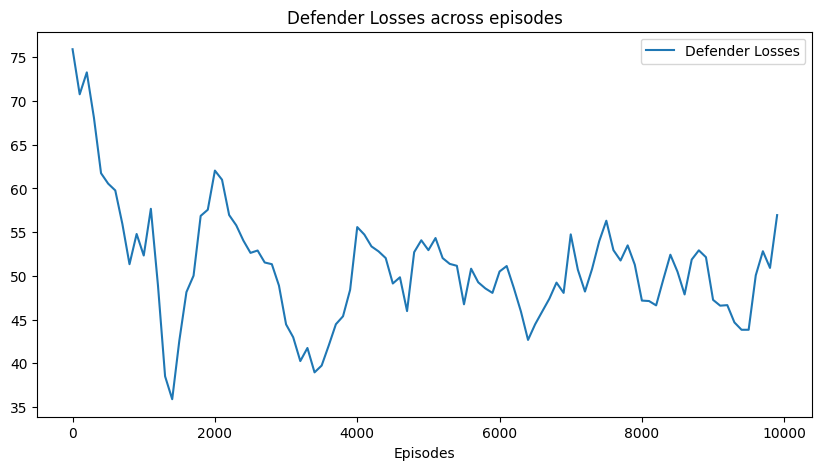

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),defender_losses, label='Defender Losses')
plt.legend()
plt.title("Defender Losses across episodes")
plt.xlabel("Episodes")

Text(0.5, 0, 'Episodes')

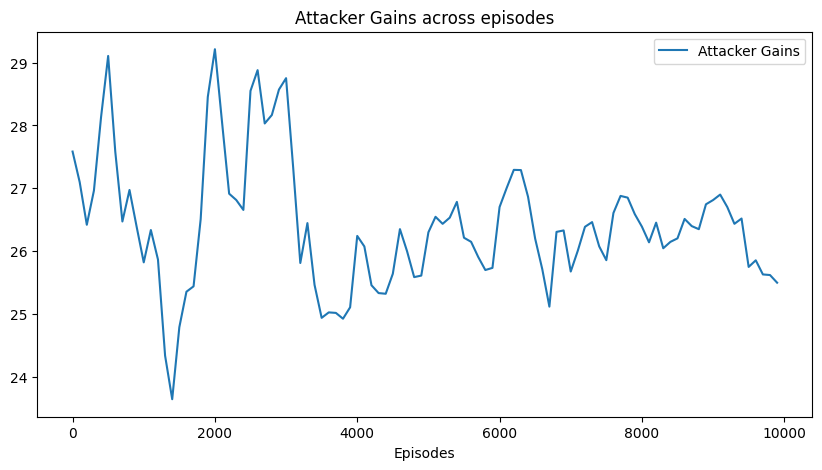

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(np.arange(0,n_episodes,100),attacker_gains, label='Attacker Gains')
plt.legend()
plt.title("Attacker Gains across episodes")
plt.xlabel("Episodes")